In [18]:
import json
data = json.load(open("../data/VHM_dataset_sft/list_sft.json", "r"))
print(len(data))

178827


In [19]:
source2data = {}
for sample in data:
    source = sample["source_dataset"]
    if source not in source2data:
        source2data[source] = []
    source2data[source].append(sample)
all_sources = list(source2data.keys())
print(all_sources)

for source in source2data:
    print(f"## {source}: ", len(source2data[source]))
    print(source2data[source][0])
    print(source2data[source][1])

['fmow', 'METER-ML', 'NWPU-RESISC45', 'RSITMD', 'UCM', 'DOIR-RSVG', 'RSVQA_LR-presence', 'RSVQA_LR-comp', 'RSVQA_LR-rural_urban', 'dior', 'dota-train', 'fair1m-train', 'dota-val', 'fair1m-train-small', 'fair1m', 'dota', 'FBP', 'deepglobe_lc', 'BANDON', 'Mts-WH', 'DOTA-train', 'MSAR', 'corwdAI', 'crowdAI']
## fmow:  6841
{'image': '100_fountain_680_3_rgb.jpg', 'source_dataset': 'fmow', 'conversations': [{'from': 'human', 'value': '<image>\n{CLS} Classify the image within one of the given classes:military facility,border checkpoint,port,railway bridge,airport hangar,helipad,road bridge,flooded road,tower,zoo,factory or powerplant,single-unit residential,place of worship,crop field,lake or pond,nuclear powerplant,aquaculture,ground transportation station,construction site,hospital,storage tank,recreational facility,electric substation,car dealership,fountain,gas station,dam,space facility,airport,smokestack,water treatment facility,oil or gas facility,office building,park,lighthouse,shipy

In [22]:
# pop examples with {VG} from data
def extract_vg(data):
    vg_data, other_data = [], []
    for sample in data:
        if "{VG}" in json.dumps(sample):
            vg_data.append(sample)
        else:
            other_data.append(sample)
    return vg_data, other_data

print(f"VG: Before {len(data)}")
vg_data, data = extract_vg(data)
print(f"VG: After {len(data)}")
print(f"VG: {len(vg_data)}")

# all sample for vg data is two round conversations
is_two_round = [len(sample["conversations"]) == 2 for sample in vg_data]
print(all(is_two_round))

# print sources for vg data
print(set([sample["source_dataset"] for sample in vg_data]))

# examples
import random
for example in random.sample(vg_data, 5):
    print(example)

VG: Before 154782
VG: After 100800
VG: 53982
True
{'DOIR-RSVG'}
{'image': '41779_18252.jpg', 'source_dataset': 'DOIR-RSVG', 'conversations': [{'from': 'human', 'value': '<image>\n{VG} the airplane on the lower left'}, {'from': 'gpt', 'value': '[[086,787,212,923]]'}]}
{'image': '44141_03784.jpg', 'source_dataset': 'DOIR-RSVG', 'conversations': [{'from': 'human', 'value': '<image>\n{VG} the blue and gray chimney'}, {'from': 'gpt', 'value': '[[410,192,707,481]]'}]}
{'image': '53168_14928.jpg', 'source_dataset': 'DOIR-RSVG', 'conversations': [{'from': 'human', 'value': '<image>\n{VG} a huge ground track field'}, {'from': 'gpt', 'value': '[[118,202,855,878]]'}]}
{'image': '40603_18457.jpg', 'source_dataset': 'DOIR-RSVG', 'conversations': [{'from': 'human', 'value': '<image>\n{VG} a basketball court is on the lower right of the train station in the middle'}, {'from': 'gpt', 'value': '[[497,783,517,820]]'}]}
{'image': '21226_18020.jpg', 'source_dataset': 'DOIR-RSVG', 'conversations': [{'from'

In [20]:
# pop examples with {CLS} from data
def extract_cls(data):
    cls_data, other_data = [], []
    for sample in data:
        if "{CLS}" in json.dumps(sample):
            cls_data.append(sample)
        else:
            other_data.append(sample)
    return cls_data, other_data

print(f"CLS: Before {len(data)}")
cls_data, data = extract_cls(data)
print(f"CLS: After {len(data)}")
print(f"CLS: {len(cls_data)}")

# all sample for cls data is two round conversations
is_two_round = [len(sample["conversations"]) == 2 for sample in cls_data]
print(all(is_two_round))

# print sources for cls data
print(set([sample["source_dataset"] for sample in cls_data]))

# examples
import random
for example in random.sample(cls_data, 5):
    print(example)

CLS: Before 178827


CLS: After 164782
CLS: 14045
True
{'UCM', 'METER-ML', 'fmow', 'RSITMD', 'NWPU-RESISC45'}
{'image': '2962_river_197.jpg', 'source_dataset': 'NWPU-RESISC45', 'conversations': [{'from': 'human', 'value': '<image>\n{CLS} Classify the image within one of the given classes:airplane,desert,mobile home park,ship,airport,forest,mountain,snowberg,baseball diamond,freeway,overpass,sparse residential,basketball court,golf course,palace,stadium,beach,ground track field,parking lot,storage tank,bridge,harbor,railway,tennis court,chaparral,industrial area,railway station,terrace,church,intersection,rectangular farmland,thermal power station,circular farmland,island,river,wetland,cloud,lake,roundabout,commercial area,meadow,runway,dense residential,medium residential,sea ice. Answer with one word or short phrase.'}, {'from': 'gpt', 'value': 'river'}]}
{'image': '4145_stadium_364_2_rgb.jpg', 'source_dataset': 'fmow', 'conversations': [{'from': 'human', 'value': '<image>\n{CLS} Classify the image within

In [21]:
# pop examples with {VQA} from data
def extract_vqa(data):
    vqa_data, other_data = [], []
    for sample in data:
        if "{VQA}" in json.dumps(sample):
            vqa_data.append(sample)
        else:
            other_data.append(sample)
    return vqa_data, other_data

print(f"VQA: Before {len(data)}")
vqa_data, data = extract_vqa(data)
print(f"VQA: After {len(data)}")
print(f"VQA: {len(vqa_data)}")

# all sample for vqa data is two round conversations
is_two_round = [len(sample["conversations"]) == 2 for sample in vqa_data]
print(all(is_two_round))

# print sources for vqa data
print(set([sample["source_dataset"] for sample in vqa_data]))

# examples
import random
for example in random.sample(vqa_data, 5):
    print(example)

VQA: Before 164782
VQA: After 154782
VQA: 10000
True
{'RSVQA_LR-presence', 'RSVQA_LR-rural_urban', 'RSVQA_LR-comp'}
{'image': '1304_13.png', 'source_dataset': 'RSVQA_LR-comp', 'conversations': [{'from': 'human', 'value': '<image>\n{VQA} Are there less roads than scrubs?'}, {'from': 'gpt', 'value': 'no'}]}
{'image': '3188_29.png', 'source_dataset': 'RSVQA_LR-comp', 'conversations': [{'from': 'human', 'value': '<image>\n{VQA} Are there more water areas than forests?'}, {'from': 'gpt', 'value': 'no'}]}
{'image': '3781_416.png', 'source_dataset': 'RSVQA_LR-comp', 'conversations': [{'from': 'human', 'value': '<image>\n{VQA} Are there more buildings than woods?'}, {'from': 'gpt', 'value': 'yes'}]}
{'image': '3090_457.png', 'source_dataset': 'RSVQA_LR-presence', 'conversations': [{'from': 'human', 'value': '<image>\n{VQA} Is a residential area present?'}, {'from': 'gpt', 'value': 'yes'}]}
{'image': '3539_711.png', 'source_dataset': 'RSVQA_LR-presence', 'conversations': [{'from': 'human', 'val

single-class classification {CLS}: 'fmow', 'METER-ML', 'NWPU-RESISC45', 'RSITMD', 'UCM'
visual grounding {VG}: 'DOIR-RSVG'
RSVQA {VQA}: 'RSVQA_LR-presence', 'RSVQA_LR-comp', 'RSVQA_LR-rural_urban'
{IDK}: fair1m, dota
{IT}: FBP, deepglobe_lc, BANDON, Mts-WH, DOTA-train, MSAR, corwdAI, crowdAI
'dior', 'dota-train', 'fair1m-train', 'dota-val', 'fair1m-train-small'


In [23]:
# pop examples with {IDK} from data (i.e. HnstD, an additional instruction dataset developed to make VLMs honest for RS image analysis)
def extract_idk(data):
    idk_data, other_data = [], []
    for sample in data:
        if "{IDK}" in json.dumps(sample):
            idk_data.append(sample)
        else:
            other_data.append(sample)
    return idk_data, other_data

print(f"IDK: Before {len(data)}")
idk_data, data = extract_idk(data)
print(f"IDK: After {len(data)}")
print(f"IDK: {len(idk_data)}")

# all sample for idk data is two round conversations
is_two_round = [len(sample["conversations"]) == 2 for sample in idk_data]
print(all(is_two_round))

# print sources for idk data
print(set([sample["source_dataset"] for sample in idk_data]))

# examples
import random
for example in random.sample(idk_data, 5):
    print(example)

IDK: Before 100800
IDK: After 55800
IDK: 45000
True
{'fair1m', 'dota', 'dota-train'}
{'image': '4785_12376__1.0__0___488.jpg', 'source_dataset': 'fair1m', 'conversations': [{'from': 'human', 'value': '<image>\n{IDK} Please specify the actual color of the Cargo Truck in this aerial image. If this question is unanswerable, please provide the reason.'}, {'from': 'gpt', 'value': 'grey.'}]}
{'image': '15377_16350__1.0__1488___1024.jpg', 'source_dataset': 'fair1m', 'conversations': [{'from': 'human', 'value': '<image>\n{IDK} Can you pinpoint the location of the Engineering Ship in the remote sensing image?\nA. top left\nB. right\nC. Sorry, the object is invisible\nD. top\nE. bottom left\nPealse select the correct answer from the above options.'}, {'from': 'gpt', 'value': 'A. top left'}]}
{'image': '15501_15256__1.0__0___488.jpg', 'source_dataset': 'fair1m', 'conversations': [{'from': 'human', 'value': '<image>\n{IDK} Can you pinpoint the location of the Intersection in the remote sensing ima

In [24]:
# pop examples with {IT} from data
def extract_it(data):
    it_data, other_data = [], []
    for sample in data:
        if "{IT}" in json.dumps(sample):
            it_data.append(sample)
        else:
            other_data.append(sample)
    return it_data, other_data

print(f"IT: Before {len(data)}")
it_data, data = extract_it(data)
print(f"IT: After {len(data)}")
print(f"IT: {len(it_data)}")

# all sample for it data is two round conversations
is_two_round = [len(sample["conversations"]) == 2 for sample in it_data]
print(all(is_two_round))

# print sources for it data
print(set([sample["source_dataset"] for sample in it_data]))

# examples
import random
for example in random.sample(it_data, 5):
    print(example)

IT: Before 55800
IT: After 30000
IT: 25800
True
{'deepglobe_lc', 'corwdAI', 'Mts-WH', 'dota-train', 'MSAR', 'dota', 'crowdAI', 'fair1m', 'BANDON', 'fmow', 'DOTA-train', 'FBP'}
{'image': '7391_P1258__1.0__4688___1152.png', 'source_dataset': 'dota', 'conversations': [{'from': 'human', 'value': '<image>\n{IT} Could you provide the authenticated dimensions of the ship, specifically its length and width?'}, {'from': 'gpt', 'value': 'The actual length of this object is: 81.00m, and the actual width is: 50.00m.'}]}
{'image': '6522_000000000690.jpg', 'source_dataset': 'corwdAI', 'conversations': [{'from': 'human', 'value': '<image>\n{IT} Please output the outlines of buildings in the vicinity of [096,466,286,780].'}, {'from': 'gpt', 'value': 'The vectorized key points of the outline of this building are <10> in number, with specific point coordinates at [(096,776),(096,466),(260,466),(283,466),(283,496),(260,496),(260,746),(283,746),(283,776),(260,776),(096,776)].'}]}
{'image': '605_0000002445

In [25]:
# pop specific examples from {IT} data
def extract_multi_label_cls(it_data):
    multi_label_cls_data, other_data = [], []
    for sample in it_data:
        if "Answer the question with some of the following categorical words or phases" in json.dumps(sample):
            multi_label_cls_data.append(sample)
        else:
            other_data.append(sample)
    return multi_label_cls_data, other_data

def extract_invisible(it_data):
    invisible_data, other_data = [], []
    for sample in it_data:
        if "not visible" in json.dumps(sample).lower():
            invisible_data.append(sample)
        else:
            other_data.append(sample)
    return invisible_data, other_data

def extract_length(it_data):
    geometric_measurement_data, other_data = [], []
    for sample in it_data:
        if "actual length" in json.dumps(sample):
            geometric_measurement_data.append(sample)
        else:
            other_data.append(sample)
    return geometric_measurement_data, other_data

def extract_type(it_data):
    type_data, other_data = [], []
    for sample in it_data:
        if "{IT} What type of image is this?" in json.dumps(sample):
            type_data.append(sample)
        else:
            other_data.append(sample)
    return type_data, other_data

def extract_resolution(it_data):
    resolution_data, other_data = [], []
    for sample in it_data:
        if "{IT} What is the spatial resolution" in json.dumps(sample):
            resolution_data.append(sample)
        else:
            other_data.append(sample)
    return resolution_data, other_data

def extract_building(it_data):
    building_data, other_data = [], []
    for sample in it_data:
        if "{IT} Please output the outlines of buildings" in json.dumps(sample):
            building_data.append(sample)
        else:
            other_data.append(sample)
    return building_data, other_data

def extract_count(it_data):
    count_data, other_data = [], []
    for sample in it_data:
        if "just answer the number" in json.dumps(sample).lower():
            count_data.append(sample)
        else:
            other_data.append(sample)
    return count_data, other_data

print(f"cls: Before {len(it_data)}")
multi_label_cls_data, it_data = extract_multi_label_cls(it_data)
print(f"cls: After {len(it_data)}")
print(f"cls: {len(multi_label_cls_data)}")

# print sources for cls data
print(set([sample["source_dataset"] for sample in multi_label_cls_data]))
# examples
import random
for example in random.sample(multi_label_cls_data, 2):
    print(example)

print(f"invisible: Before {len(it_data)}")
invisible_data, it_data = extract_invisible(it_data)
print(f"invisible: After {len(it_data)}")
print(f"invisible: {len(invisible_data)}")

# print sources for invisible data
print(set([sample["source_dataset"] for sample in invisible_data]))
# examples
import random
for example in random.sample(invisible_data, 2):
    print(example)

print(f"geometric_measurement: Before {len(it_data)}")
length_data, it_data = extract_length(it_data)
print(f"geometric_measurement: After {len(it_data)}")
print(f"geometric_measurement: {len(length_data)}")

# print sources for length data
print(set([sample["source_dataset"] for sample in length_data]))
# examples
import random
for example in random.sample(length_data, 2):
    print(example)

print(f"type: Before {len(it_data)}")
type_data, it_data = extract_type(it_data)
print(f"type: After {len(it_data)}")
print(f"type: {len(type_data)}")

# print sources for type data
print(set([sample["source_dataset"] for sample in type_data]))
# examples
import random
for example in random.sample(type_data, 2):
    print(example)

print(f"resolution: Before {len(it_data)}")
resolution_data, it_data = extract_resolution(it_data)
print(f"resolution: After {len(it_data)}")
print(f"resolution: {len(resolution_data)}")

# print sources for resolution data
print(set([sample["source_dataset"] for sample in resolution_data]))
# examples
import random
for example in random.sample(resolution_data, 2):
    print(example)

print(f"building: Before {len(it_data)}")
building_data, it_data = extract_building(it_data)
print(f"building: After {len(it_data)}")
print(f"building: {len(building_data)}")

# print sources for building data
print(set([sample["source_dataset"] for sample in building_data]))

# examples
import random
for example in random.sample(building_data, 2):
    print(example)

print(f"count: Before {len(it_data)}")
count_data, it_data = extract_count(it_data)
print(f"count: After {len(it_data)}")
print(f"count: {len(count_data)}")

# print sources for count data
print(set([sample["source_dataset"] for sample in count_data]))
# examples
import random
for example in random.sample(count_data, 2):
    print(example)

cls: Before 25800
cls: After 23800
cls: 2000
{'deepglobe_lc'}
{'image': '364_759668_sat__512__1936___1024.jpg', 'source_dataset': 'deepglobe_lc', 'conversations': [{'from': 'human', 'value': '<image>\n{IT} Answer the question with some of the following categorical words or phases:urban land,agriculture land,rangeland,forest land,water,barren land.Can you describe the land cover variety present in this remote sensing view?'}, {'from': 'gpt', 'value': 'barren land, urban land, agriculture land, rangeland'}]}
{'image': '1437_300967_sat__512__1536___1936.jpg', 'source_dataset': 'deepglobe_lc', 'conversations': [{'from': 'human', 'value': '<image>\n{IT} Answer the question with some of the following categorical words or phases:urban land,agriculture land,rangeland,forest land,water,barren land.Can you point out the various land cover categories in this aerial photograph?'}, {'from': 'gpt', 'value': 'agriculture land'}]}
invisible: Before 23800
invisible: After 22800
invisible: 1000
{'dota-t

{'dota-train', 'dior', 'fair1m-train', 'fair1m-train-small', 'dota-val'}
30000
{'image': '1760_1804.jpg', 'source_dataset': 'fair1m-train-small', 'conversations': [{'from': 'human', 'value': '<image>\n What type of airplane is present in the image?'}, {'from': 'gpt', 'value': ' There are two Airbus A220 airplanes in the image.'}, {'from': 'human', 'value': ' What is the function of the large white hangar?'}, {'from': 'gpt', 'value': ' Hangars are typically used to store, maintain, and repair aircraft. This hangar may serve a similar purpose at this airport.'}, {'from': 'human', 'value': ' Are there any undeveloped areas near the airport?'}, {'from': 'gpt', 'value': ' Yes, there is a large patch of undeveloped land adjacent to the runway.'}, {'from': 'human', 'value': ' What might be the purpose of this undeveloped land?'}, {'from': 'gpt', 'value': " Undeveloped land near airports can be used for future expansion of the airport's facilities, such as additional runways, terminals, or car

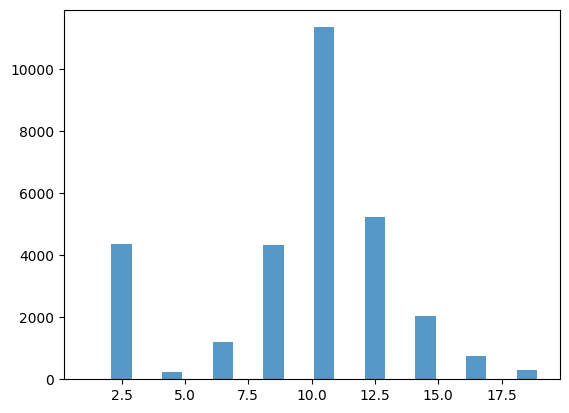

: 

In [26]:
# print sources for the rest data (the VersaD-Instruct comprising 30K RS images, with 26K images dedicated to conversation and 4K to complex reasoning)
print(set([sample["source_dataset"] for sample in data]))
print(len(data))
# examples
import random
for example in random.sample(data, 20):
    print(example)
# get rounds number and plot statistics
instruct_rounds = [len(sample["conversations"]) for sample in data]
import matplotlib.pyplot as plt
plt.hist(instruct_rounds, bins=range(1, 20), alpha=0.75, rwidth=0.8)
plt.show()

Eval Set

In [3]:
import os
import json

data_root = '/mnt/petrelfs/liqingyun/RSCoAgent/playground/data/VHM_eval_dataset/datasets_eval'

json_filepath_list = [os.path.join(data_root, filename) for filename in os.listdir(data_root) if filename.endswith('.json')]
json_filepath_list.sort()
for json_filepath in json_filepath_list:
    data = json.load(open(json_filepath, "r"))
    print(f"## {os.path.basename(json_filepath)}: ", len(data))

## RSVQA_HR-comp_RSVQA.json:  1000
## RSVQA_HR-presence_RSVQA.json:  1000
## RSVQA_LR-comp_RSVQA.json:  950
## RSVQA_LR-presence_RSVQA.json:  950
## RSVQA_LR-rural_urban_RSVQA.json:  100
## VG_DOIR_RSVG_test.json:  7500
## abspos_dota-test_mc.json:  112
## abspos_false_dota-test_adversarial_mc.json:  100
## abspos_false_dota-test_popular_mc.json:  100
## abspos_false_dota-test_random_mc.json:  100
## bfv_crowdai_val.json:  200
## cls_AID.json:  3000
## cls_METER_ML.json:  565
## cls_NWPU_RESISC45.json:  3150
## cls_SIRI_WHU.json:  2400
## cls_WHU_RS19.json:  1000
## color_dota-test_fair1m-val_open.json:  200
## color_false_dota-test_adversarial_open.json:  100
## color_false_dota-test_popular_open.json:  100
## color_false_dota-test_random_open.json:  100
## color_false_pan_dota-test.json:  100
## counting_dota-test_open.json:  120
## gsd_dota_fbp.json:  360
## imgType_mcq.json:  20
## mlc_fbp_test.json:  6240
## mlc_gid_test.json:  6240
## obj_meas_dota_test.json:  200
## presence_mo_